In [14]:
from sentence_transformers import SentenceTransformer
from pydantic import BaseModel
from typing import List
from sklearn.manifold import TSNE
from scipy.spatial import distance
from openai import OpenAI
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import os
import re

load_dotenv()

llm_client = OpenAI(
    api_key=os.getenv('GROQ_TOKEN'),
    base_url=os.getenv('BASE_URL_GROQ')
)

def clean_response(text:str) -> str:
    # Паттерн ищет всё между <think> и </think>, включая переносы строк
    pattern = r"<think>.*?</think>"
    
    # Заменяем найденное на пустоту и убираем лишние пробелы по краям
    cleaned_text = re.sub(pattern, "", text, flags=re.DOTALL).strip()
    return cleaned_text

class EmbeddingData(BaseModel):
    embedding: List[float]
    index: int
    object: str = "embedding"

class EmbeddingResponse(BaseModel):
    data: List[EmbeddingData]
    model: str
    object: str = "list"
    usage: dict = {"prompt_tokens": 0, "total_tokens": 0}

class LocalEmbeddings:
    def __init__(self, model_name='intfloat/multilingual-e5-small'):
        self.model = SentenceTransformer(model_name)
        self.model_name = model_name

    def create(self, input, model=None):
        # Если пришла строка, делаем список
        sentences = [input] if isinstance(input, str) else input
        vectors = self.model.encode(sentences)
        
        # Формируем ответ в стиле OpenAI
        data_list = [
            EmbeddingData(embedding=v.tolist(), index=i) 
            for i, v in enumerate(vectors)
        ]
        return EmbeddingResponse(data=data_list, model=model or self.model_name)

client = type('Mock', (), {'embeddings': LocalEmbeddings()})()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1575.99it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# Часть 1
## Задача 1.1

text = "Искусственный интеллект меняет мир"

def get_embeddings(text):
    response = client.embeddings.create(
        model="multilingual-e5-small", # Здесь модель из sentence_transformers
        input=text
    )

    response_dict = response.model_dump()

    return [data['embedding'] for data in response_dict['data']]

text_embedding = get_embeddings(text)[0]

print(f'Длина вектора: {len(text_embedding)}')
print(f'Первые 5 чисел: {text_embedding[:5]}')
print(f'Тип: {type(text_embedding[0])}')

Длина вектора: 384
Первые 5 чисел: [0.049845028668642044, 0.01096984650939703, -0.05078640580177307, -0.02982422150671482, 0.06729744374752045]
Тип: <class 'float'>


In [6]:
## Часть 1.2

texts = [
    "Кот",
    "Кот сидит на диване",
    "Кот сидит на диване и смотрит в окно на падающий снег, мечтая о приключениях"
]

texts_embeddings = get_embeddings(texts)

length = len(texts_embeddings[0])
answer = True

for i, text in enumerate(texts):
    print(f'{text} -> длина вектора: {len(texts_embeddings[i])}')
    if i != 0 and len(texts_embeddings[i]) != length:
        answer = False

print(f"Все длины одинаковые: {answer}")

Кот -> длина вектора: 384
Кот сидит на диване -> длина вектора: 384
Кот сидит на диване и смотрит в окно на падающий снег, мечтая о приключениях -> длина вектора: 384
Все длины одинаковые: True


In [8]:
# Часть 2
## Задача 2.1

products = [
    {"name": "Ноутбук MacBook Pro", "category": "Электроника"},
    {"name": "Беспроводные наушники Sony", "category": "Электроника"},
    {"name": "Кроссовки Nike Air Max", "category": "Обувь"},
    {"name": "Кожаные ботинки", "category": "Обувь"},
    {"name": "Роман «Мастер и Маргарита»", "category": "Книги"},
    {"name": "Учебник по машинному обучению", "category": "Книги"},
    {"name": "Смартфон Samsung Galaxy", "category": "Электроника"},
    {"name": "Кеды Converse", "category": "Обувь"},
]

def create_embeddings(texts):
    response = client.embeddings.create(
        model = 'multilingual-e5-small',
        input = texts
    )

    response_dict = response.model_dump()

    return [data['embedding'] for data in response_dict['data']]

products_names = [product['name'] for product in products]

products_embeddings = create_embeddings(products_names)

for i, product in enumerate(products):
    product['embedding'] = products_embeddings[i]

print(f'Товаров с эмбеддингами: {sum(1 for item in products if 'embedding' in item)}')
print(f'Первый товар: {products[0]['name']}, длина вектора: {len(products[0]['embedding'])}')

Товаров с эмбеддингами: 8
Первый товар: Ноутбук MacBook Pro, длина вектора: 384


In [16]:
# Часть 3
## Задача 3.1

words_pairs = [
    ('собака', "пес"),
    ("автомобиль", "машина"),
    ("кот","квантовая физика"),
    ("программирование", 'Python')
]

for word1, word2 in words_pairs:
    emb1 = create_embeddings(word1)[0]
    emb2 = create_embeddings(word2)[0]

    dist = distance.cosine(emb1, emb2)
    
    system_prompt = '''Ты ИИ асситент по классификации схожести смыслов пар слов. Тебе будут предоставляеться пары слов которые сравнивались и результат работы distance.cosine функции внутрь которой передаются два вектора (embedding). Каждый результат ты должен классифицировать по следующим категориям:
    - Очень похожи
    - Похожи
    - Не похожи
    - Связаны
    - Противополжности
    
    <блок структуры вывода>
    "слово1" - "слово2": расстояние = число (категория классификации)
    <блок структуры вывода>'''

    user_prompt = f'Первое слово: {word1}. Второе слово: {word2}. Расстояние между векторами: {round(dist, 4)}'

    llm_response = llm_client.chat.completions.create(
        model=os.getenv('GROQ_MODEL'),
        messages=[
            {'role':'system', 'content':system_prompt},
            {'role':'user', 'content':user_prompt}
        ]
    )

    print(clean_response(llm_response.choices[0].message.content))

"собака" - "пес": расстояние = 0.0978 (Очень похожи)
"автомобиль" - "машина": расстояние = 0.0528 (Очень похожи)
"кот" - "квантовая физика": расстояние = 0.1798 (Не похожи)  
*Комментарий:* Несмотря на низкое числовое расстояние, тематически эти концепции не связаны. Квантовая физика изучает микромир, а "кот" относится к категории животных. Вероятно, расхождение связано с шумом в embeddings или артефактом модели.*
"программирование" - "Python": 0.1569 (Связаны)


In [30]:
## Задача 3.2

products = [
    {"name": "Ноутбук MacBook Pro", "category": "Электроника"},
    {"name": "Беспроводные наушники Sony", "category": "Электроника"},
    {"name": "Кроссовки Nike Air Max", "category": "Обувь"},
    {"name": "Кожаные ботинки", "category": "Обувь"},
    {"name": "Роман «Мастер и Маргарита»", "category": "Книги"},
    {"name": "Учебник по машинному обучению", "category": "Книги"},
    {"name": "Смартфон Samsung Galaxy", "category": "Электроника"},
    {"name": "Кеды Converse", "category": "Обувь"},
]

products_names = [product['name'] for product in products]

products_embeddings = create_embeddings(products_names)

for i, product in enumerate(products):
    product['embedding'] = products_embeddings[i]

queries = [
    "гаджет для музыки",
    "литература русских классиков",
    "спортивная обувь для бега",
]

for query in queries:
    print(f'Запрос: "{query}"')
    query_emb = create_embeddings(query)[0]
    dist_list = []
    for product in products:
        dist_list.append(distance.cosine(query_emb, product['embedding']))
    indexed_dist_list = list(zip(range(len(dist_list)), dist_list))
    sorted_indexed_dist_list = sorted(indexed_dist_list, key = lambda x: x[1])
    for i, answer in enumerate(sorted_indexed_dist_list[:3]):
        print(f'    {i+1}. {products[answer[0]]['name']} (dist={round(answer[1], 4)})')

Запрос: "гаджет для музыки"
    1. Беспроводные наушники Sony (dist=0.1264)
    2. Учебник по машинному обучению (dist=0.1576)
    3. Смартфон Samsung Galaxy (dist=0.161)
Запрос: "литература русских классиков"
    1. Роман «Мастер и Маргарита» (dist=0.1502)
    2. Кожаные ботинки (dist=0.1829)
    3. Кеды Converse (dist=0.1945)
Запрос: "спортивная обувь для бега"
    1. Кожаные ботинки (dist=0.1236)
    2. Кроссовки Nike Air Max (dist=0.1492)
    3. Кеды Converse (dist=0.167)


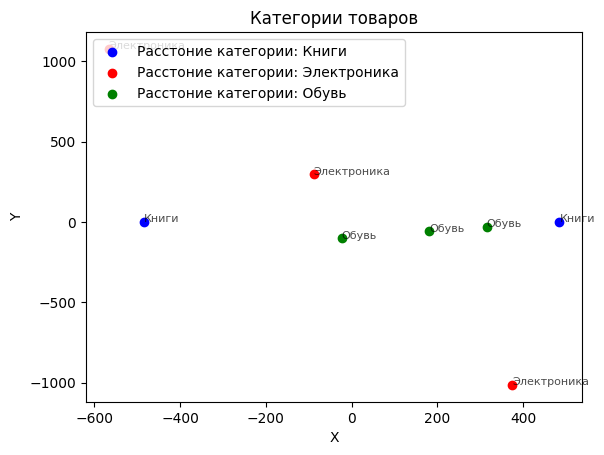

In [ ]:
# Часть 4
## Задача 4.1

embeddings = [product['embedding'] for product in products]
categories = [product['category'] for product in products]
set_categories = list(set(categories))
categories_dict = {cat:[] for cat in set_categories}
color_dict = {cat: color for cat, color in zip(set_categories, ['blue','red','green'])}

for product in products:
    for cat in categories_dict:
        if product['category'] == cat:
            categories_dict[cat].append(product['embedding'])

for cat in categories_dict:
    tsne = TSNE(n_components=2, perplexity=int(len(categories_dict[cat])/2))
    embeddings_2d = tsne.fit_transform(np.array(categories_dict[cat]))
    plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], c=color_dict[cat], label=f'Расстоние категории: {cat}')

    for j in range(len(embeddings_2d)):
        plt.annotate(cat, (embeddings_2d[j, 0], embeddings_2d[j, 1]), 
                     fontsize=8, alpha=0.7)

plt.title('Категории товаров')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper left')
plt.show()

# Товары не группируются в одном месте по причине того что их слишком мало и также модель создает в разы меньше измерений в embedding

In [ ]:
# Часть 5
## Задача 5.1

new_items = [
    "Планшет iPad",
    "Сапоги зимние женские",
    "Детектив Агаты Кристи",
    "Наушники JBL",
    "Кроссовки Adidas",
]

new_embeddings = create_embeddings(new_items)

for item_name, item_emb in zip(new_items, new_embeddings):
    distances = []
    for product in products:
        dist = distance.cosine(item_emb, product['embedding'])
        distances.append(dist)
    
    nearest_idx = np.argmin(distances)
    nearest_product = products[nearest_idx]

    print(f'''{item_name} -> {nearest_product['category']} (ближайший: {nearest_product['name']})''')

# Результат не плохой но есть ошибки в классификации думаю это по причине использования слабой модели для embedding-а

Планшет iPad -> Электроника (ближайший: Ноутбук MacBook Pro)
Сапоги зимние женские -> Обувь (ближайший: Кожаные ботинки)
Детектив Агаты Кристи -> Обувь (ближайший: Кеды Converse)
Наушники JBL -> Электроника (ближайший: Беспроводные наушники Sony)
Кроссовки Adidas -> Обувь (ближайший: Кроссовки Nike Air Max)


In [ ]:
# Задача 6

faq = [
    {"question": "Как отменить заказ?", "answer": "Зайдите в раздел 'Мои заказы' и нажмите 'Отменить'."},
    {"question": "Когда придёт моя посылка?", "answer": "Срок доставки 2-5 рабочих дней."},
    {"question": "Как вернуть товар?", "answer": "Возврат возможен в течение 14 дней с момента получения."},
    {"question": "Как изменить адрес доставки?", "answer": "Свяжитесь с поддержкой до момента отправки заказа."},
    {"question": "Принимаете ли оплату картой?", "answer": "Да, принимаем Visa, MasterCard и МИР."},
    {"question": "Есть ли у вас программа лояльности?", "answer": "Да, при каждой покупке начисляются бонусные баллы."},
]

questions = [f['question'] for f in faq]
q_emb = create_embeddings(questions)

for i, emb in enumerate(q_emb):
    faq[i]['embedding'] = emb

def find_answer(user_query:str, faq:list[dict], threshold:float=0.2) -> str:
    uq_emb = create_embeddings(user_query)[0]
    distances = []
    for f in faq:
        dist = distance.cosine(uq_emb, f['embedding'])
        distances.append(dist)
    
    min_dist = np.min(distances)
    
    if min_dist <= threshold:
        nearest_idx = np.argmin(distances)
        nearest_answer = faq[nearest_idx]
        return nearest_answer['answer']
    else:
        return 'Извините, не нашли ответ на ваш вопрос.'

user_queries = [
    "Хочу отказаться от покупки",           # → отмена заказа
    "Сколько ждать доставку?",               # → срок доставки
    "Могу ли я расплатиться Visa?",          # → оплата картой
    "Как приготовить борщ?",                 # → не найдено
]

for query in user_queries:
    answer = find_answer(query, faq)
    print(f'Запрос: {query}')
    print(f'Ответ: {answer}')

# Все работает но из-за ограничений модели не может получить идеальный результат

Запрос: Хочу отказаться от покупки
Ответ: Зайдите в раздел 'Мои заказы' и нажмите 'Отменить'.
Запрос: Сколько ждать доставку?
Ответ: Срок доставки 2-5 рабочих дней.
Запрос: Могу ли я расплатиться Visa?
Ответ: Да, принимаем Visa, MasterCard и МИР.
Запрос: Как приготовить борщ?
Ответ: Срок доставки 2-5 рабочих дней.
